# 05_02 Hydrography Map

## 1. Introduction

Hydrography is the study and mapping of surface water features, including rivers, streams, creeks, lakes, ponds, wetlands, and other bodies of water. Within ecology, hydrography represents one of the most important abiotic components of an ecosystem because water strongly influences soil formation, vegetation, wildlife distributions, nutrient cycling, erosion, and watershed processes. Nearly every ecological model depends, either directly or indirectly, on the movement and availability of water.

The objective of this notebook is to construct a unified hydrography dataset for the Waterloo Region by evaluating and integrating publicly available geographic datasets from multiple levels of government. Although several municipal governments maintain their own environmental datasets, the Region of Waterloo also publishes regional datasets that often incorporate municipal information. Before combining these datasets, however, it is important to determine whether the regional datasets already contain the municipal features or whether additional information must be merged.

Rather than assuming that one dataset is complete, this notebook demonstrates a reproducible workflow for evaluating multiple geographic data sources. This approach can be applied to any study area and serves as an important example of data validation prior to ecological analysis.

The hydrography layer produced here will become one of the primary environmental layers used throughout the remainder of this project. Later notebooks will combine this dataset with elevation, land cover, soils, vegetation, and species distributions to construct progressively more sophisticated ecological models.

### Datasets Used

The following GeoJSON datasets are evaluated in this notebook.

#### Regional (Region of Waterloo)

- Creeks
- Rivers
- Significant Valleys *(used later in the Land Cover chapter)*
- Provincially Significant Wetlands *(used later in the Land Cover chapter)*
- Environmentally Sensitive Landscapes *(not used in this notebook)*
- Environmentally Sensitive Policy Areas *(not used in this notebook)*

#### Municipal (City of Waterloo)

- Creeks
- Water Bodies

#### Municipal (City of Kitchener)

- Rivers, Creeks, Ponds and Lakes

Although additional municipalities exist within Waterloo Region, the Region of Waterloo hydrography datasets already include water features extending throughout the regional boundary. Therefore, only the municipalities with independently published hydrography datasets are compared here.

### Objectives

By the end of this notebook we will:

1. Load and inspect each hydrography dataset.
2. Compare municipal and regional datasets.
3. Determine whether the regional datasets fully contain the municipal datasets.
4. Identify situations where additional merging is required.
5. Produce a unified hydrography dataset for future notebooks.
6. Visualize the final hydrography layer in both two and three dimensions.

The final merged dataset will serve as the hydrological foundation for future ecological analyses, including watershed delineation, land cover mapping, habitat connectivity modeling, and ecosystem simulations.

## 2. Imports

In [56]:
# ============================================================
# 2. Imports
# ============================================================

from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import rasterio

import plotly.graph_objects as go

from shapely.ops import unary_union

from IPython.display import display

## 3. Load Data

Before comparing or combining datasets, each GeoJSON file is loaded independently. Keeping datasets separate during the initial stages allows us to inspect their coordinate reference systems, geometry types, spatial extents, feature counts, and other metadata before deciding whether any preprocessing or merging is necessary.

This staged workflow is considered good scientific practice because it avoids making assumptions about dataset compatibility before they have been verified.

For convenience, the project stores hydrography datasets according to their source:

- Municipal datasets are organized by municipality.
- Regional datasets are organized separately.
- Elevation data is stored independently because it serves as the base terrain model for later visualization.

Each dataset remains unchanged until its quality has been assessed.

In [57]:
# ============================================================
# Define Project Paths
# ============================================================

project_root = Path("../../")

data_dir = project_root / "data"

geohub_dir = data_dir / "Geohub"

municipal_dir = geohub_dir / "Municipal"

regional_dir = geohub_dir / "Regional" / "Waterloo"

elevation_dir = data_dir / "Elevation"

In [58]:
# ============================================================
# Municipal Datasets
# ============================================================

waterloo_creeks = gpd.read_file(
    municipal_dir / "Waterloo" / "Creeks.geojson"
)

waterloo_water = gpd.read_file(
    municipal_dir / "Waterloo" / "Water_Bodies.geojson"
)

kitchener_water = gpd.read_file(
    municipal_dir / "Kitchener" / "Rivers_Creeks_Ponds_and_Lakes.geojson"
)

In [59]:
# ============================================================
# Regional Datasets
# ============================================================

regional_creeks = gpd.read_file(
    regional_dir / "Creeks.geojson"
)

regional_rivers = gpd.read_file(
    regional_dir / "Rivers.geojson"
)

In [60]:
# ============================================================
# Digital Elevation Model
# ============================================================

dem_path = elevation_dir / "clipped_DEM.tif"

## 4. Validate Data

Before performing any spatial analysis, the integrity of each dataset must be verified.

Geographic datasets obtained from different organizations occasionally contain invalid geometries such as self-intersecting polygons, duplicate vertices, improperly closed rings, or other topological errors. Although these issues are often invisible during visualization, they can cause spatial operations such as intersections, overlays, buffering, containment testing, and unions to fail.

To ensure that all subsequent analyses operate correctly, each dataset is checked for invalid geometries. Whenever an invalid feature is detected, it is repaired automatically using Shapely's geometry validation tools.

Performing this validation at the beginning of the workflow improves reproducibility and avoids subtle errors that might otherwise propagate through later ecological analyses.

In [61]:
# ============================================================
# Validate Geometries
# ============================================================

def validate_geometries(gdf, name):

    invalid = (~gdf.geometry.is_valid).sum()

    print(f"{name}")
    print(f"Invalid geometries: {invalid}")

    if invalid > 0:

        print("Repairing...")

        gdf = gdf.copy()

        # Shapely 2.x
        gdf.geometry = gdf.geometry.make_valid()

    print()

    return gdf

In [62]:
waterloo_creeks = validate_geometries(
    waterloo_creeks,
    "Waterloo Creeks"
)

waterloo_water = validate_geometries(
    waterloo_water,
    "Waterloo Water Bodies"
)

kitchener_water = validate_geometries(
    kitchener_water,
    "Kitchener Water"
)

regional_creeks = validate_geometries(
    regional_creeks,
    "Regional Creeks"
)

regional_rivers = validate_geometries(
    regional_rivers,
    "Regional Rivers"
)

Waterloo Creeks
Invalid geometries: 0

Waterloo Water Bodies
Invalid geometries: 1
Repairing...

Kitchener Water
Invalid geometries: 7
Repairing...

Regional Creeks
Invalid geometries: 0

Regional Rivers
Invalid geometries: 1
Repairing...



## 5. Dataset Comparison

Before combining hydrography datasets from multiple government sources, it is important to evaluate both their quality and their compatibility.

Several questions should be answered before any merging is attempted.

- Do the datasets use the same coordinate reference system (CRS)?
- Do they represent similar geographic extents?
- Are the geometry types compatible?
- How many individual features are present?
- Do the municipal datasets contribute new information beyond the regional datasets?

Whenever possible, similar feature types should be compared directly. For example, municipal creek datasets are compared with regional creek datasets rather than with all regional hydrography combined. Comparing similar feature types reduces ambiguity and produces more meaningful results.

In practice, however, government datasets are not always organized consistently. Some municipalities publish separate datasets for rivers, creeks, lakes, and ponds, whereas others combine multiple feature types into a single layer. In these situations, comparisons are performed against the combined regional hydrography because a one-to-one comparison is not possible.

The objective is therefore not to determine whether two datasets are identical, but rather whether they appear to represent the same real-world hydrographic features.

In [68]:
# ============================================================
# Dataset Summary Function
# ============================================================

def summarize_dataset(name, gdf):

    return {
        "Dataset": name,
        "Features": len(gdf),
        "Geometry": gdf.geom_type.unique().tolist(),
        "CRS": str(gdf.crs),
        "Bounds": tuple(np.round(gdf.total_bounds, 2))
    }

In [69]:
# ============================================================
# Build Summary Table
# ============================================================

summary = pd.DataFrame([

    summarize_dataset("Waterloo Creeks", waterloo_creeks),
    summarize_dataset("Waterloo Water Bodies", waterloo_water),
    summarize_dataset("Kitchener Water", kitchener_water),

    summarize_dataset("Regional Creeks", regional_creeks),
    summarize_dataset("Regional Rivers", regional_rivers)

])

display(summary)

,Dataset,Features,Geometry,CRS,Bounds
0,Waterloo Creeks,318,"[LineString, MultiLineString]",EPSG:4326,"(-80.62, 43.44, -80.48, 43.53)"
1,Waterloo Water Bodies,187,"[Polygon, MultiPolygon]",EPSG:4326,"(-80.62, 43.44, -80.47, 43.53)"
2,Kitchener Water,125,"[Polygon, MultiPolygon]",EPSG:4326,"(-80.56, 43.36, -80.39, 43.51)"
3,Regional Creeks,5457,"[LineString, MultiLineString]",EPSG:4326,"(-80.87, 43.26, -80.19, 43.69)"
4,Regional Rivers,85,"[Polygon, MultiPolygon]",EPSG:4326,"(-80.85, 43.26, -80.27, 43.65)"


### Feature Matching Between Comparable Datasets

Rather than testing whether one dataset is mathematically contained within another, this notebook evaluates whether municipal hydrographic features appear to represent the same real-world water features as the corresponding regional datasets.

Conceptually, rather than requiring the strict set relationship

$$
M \subseteq R,
$$

we instead seek the more practical GIS relationship

$$
M \approx R,
$$

where the municipal and regional datasets describe the same real-world features, even if their geometries differ slightly due to differences in mapping precision, update dates, digitization methods, or spatial resolution.

Whenever possible, comparisons should be performed between similar feature types. For example,

- Municipal creeks → Regional creeks
- Municipal rivers → Regional rivers

Comparing equivalent feature types produces the most meaningful results because both datasets are intended to represent the same physical features.

Unfortunately, the available hydrography datasets are not organized consistently.

For example, the City of Waterloo publishes separate datasets for **Creeks** and **Water Bodies**, whereas the City of Kitchener combines rivers, creeks, ponds, and lakes into a single hydrography layer. At the regional level, however, only separate **Rivers** and **Creeks** datasets are currently available. No equivalent regional dataset describing lakes and ponds was available for this analysis.

Although the Region of Waterloo also publishes a **Provincially Significant Wetlands** dataset, wetland boundaries represent ecological habitats rather than the physical extent of lakes or ponds. Consequently, wetlands cannot be used as a substitute for missing water body datasets.

As a result, the Waterloo **Water Bodies** dataset cannot be meaningfully compared with the regional hydrography because the datasets describe different classes of water features.

Similarly, comparisons involving the Kitchener hydrography layer must be interpreted with caution. Because rivers, creeks, ponds, and lakes are combined into a single municipal dataset, some legitimate lakes or ponds may intersect regional rivers or creeks simply because they are hydrologically connected. These intersections represent genuine environmental relationships rather than duplicate observations, making automatic feature matching considerably more difficult.

For these reasons, the Waterloo **Water Bodies** dataset is excluded from the feature-matching analysis. It is nevertheless retained for visualization and will later be incorporated into the final hydrography layer because it contains unique ecological information not represented elsewhere.

This exercise illustrates an important principle of geographic data integration: before datasets can be merged automatically, they must first be evaluated for conceptual compatibility. Datasets describing different feature classes should not be compared solely on the basis of geometric overlap, since spatial intersections often reflect real environmental relationships rather than duplicated data.

In [70]:
# ============================================================
# Combined Regional Hydrography
# ============================================================

regional_combined = pd.concat(
    [
        regional_creeks,
        regional_rivers
    ],
    ignore_index=True
)

regional_combined.geometry = regional_combined.geometry.make_valid()

regional_union = unary_union(regional_combined.geometry)

In [71]:
# ============================================================
# Feature Matching Test
# ============================================================

def check_feature_matching(
    municipal_name,
    municipal,
    regional_name,
    regional_union
):

    matched = municipal.geometry.intersects(regional_union)

    total = len(municipal)

    matched_count = matched.sum()

    unmatched = total - matched_count

    print("=" * 70)

    print(f"Municipal Dataset : {municipal_name}")

    print(f"Regional Dataset  : {regional_name}")

    print("-" * 70)

    print(f"Municipal Features          : {total}")

    print(f"Matching Regional Features  : {matched_count}")

    print(f"Potentially Missing Features: {unmatched}")

    print()

    if unmatched == 0:

        print("Conclusion")

        print(
            f"The regional dataset appears to represent all features "
            f"contained within the municipal dataset."
        )

        print(
            "No additional hydrographic features appear to require merging."
        )

    else:

        print("Conclusion")

        print(
            f"The regional dataset may be missing approximately "
            f"{unmatched} municipal feature(s)."
        )

        print(
            "These features should be reviewed visually before "
            "constructing the final hydrography layer."
        )

    print("=" * 70)

    print()

In [72]:
check_feature_matching(
    "Waterloo Creeks",
    waterloo_creeks,
    "Regional Creeks",
    unary_union(regional_creeks.geometry)
)

Municipal Dataset : Waterloo Creeks
Regional Dataset  : Regional Creeks
----------------------------------------------------------------------
Municipal Features          : 318
Matching Regional Features  : 256
Potentially Missing Features: 62

Conclusion
The regional dataset may be missing approximately 62 municipal feature(s).
These features should be reviewed visually before constructing the final hydrography layer.



In [73]:
check_feature_matching(
    "Kitchener Rivers, Creeks, Ponds and Lakes",
    kitchener_water,
    "Combined Regional Hydrography",
    regional_union
)

Municipal Dataset : Kitchener Rivers, Creeks, Ponds and Lakes
Regional Dataset  : Combined Regional Hydrography
----------------------------------------------------------------------
Municipal Features          : 125
Matching Regional Features  : 86
Potentially Missing Features: 39

Conclusion
The regional dataset may be missing approximately 39 municipal feature(s).
These features should be reviewed visually before constructing the final hydrography layer.



## 6. Visual Comparison

Although the previous section performed a quantitative containment analysis, visual inspection remains an important step in geographic data validation. Spatial datasets originating from different organizations may exhibit subtle differences that are not immediately apparent from summary statistics alone. Examples include slight positional offsets, differences in feature boundaries, varying levels of geometric detail, or discrepancies introduced during data collection and processing.

This section overlays the municipal and regional hydrography datasets using different colors to allow direct visual comparison. The resulting maps provide an opportunity to verify the containment analysis and identify any unexpected inconsistencies before constructing the final hydrography layer.

Three comparisons are performed:

1. Waterloo Creeks compared with the Regional Creeks dataset.
2. Waterloo Water Bodies compared with the Regional hydrography.
3. Kitchener Rivers, Creeks, Ponds and Lakes compared with the Regional hydrography.

If the municipal features are visually contained within the regional datasets, this provides additional confidence that the regional hydrography is sufficiently complete for future ecological analyses.

In [74]:
# ============================================================
# Plot Comparison Helper
# ============================================================

def compare_datasets(
    municipal,
    regional,
    municipal_name,
    regional_name,
    figsize=(8, 8)
):

    fig, ax = plt.subplots(figsize=figsize)

    regional.plot(
        ax=ax,
        color="steelblue",
        edgecolor="black",
        linewidth=0.5,
        alpha=0.6,
        label=regional_name
    )

    municipal.plot(
        ax=ax,
        color="orange",
        edgecolor="red",
        linewidth=1,
        alpha=0.8,
        label=municipal_name
    )

    ax.set_title(f"{municipal_name} vs {regional_name}")

    ax.legend()

    ax.set_axis_off()

    plt.show()

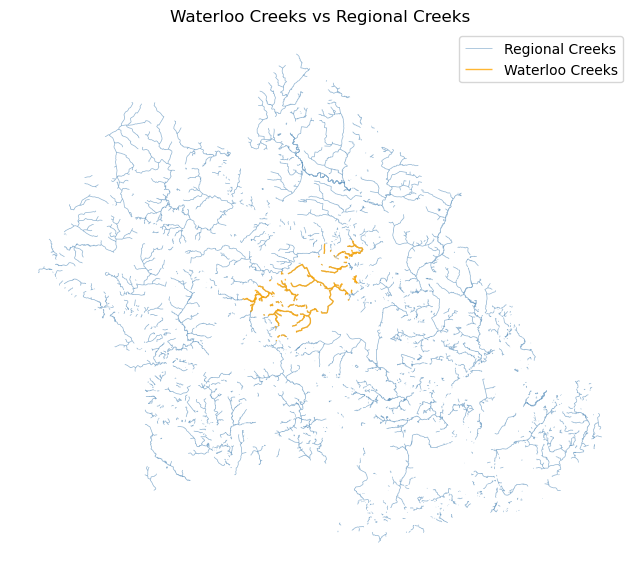

In [75]:
# Waterloo Creeks vs Regional Creeks

compare_datasets(
    waterloo_creeks,
    regional_creeks,
    "Waterloo Creeks",
    "Regional Creeks"
)

C:\Users\brody\AppData\Local\Temp\ipykernel_20568\355364513.py:35: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


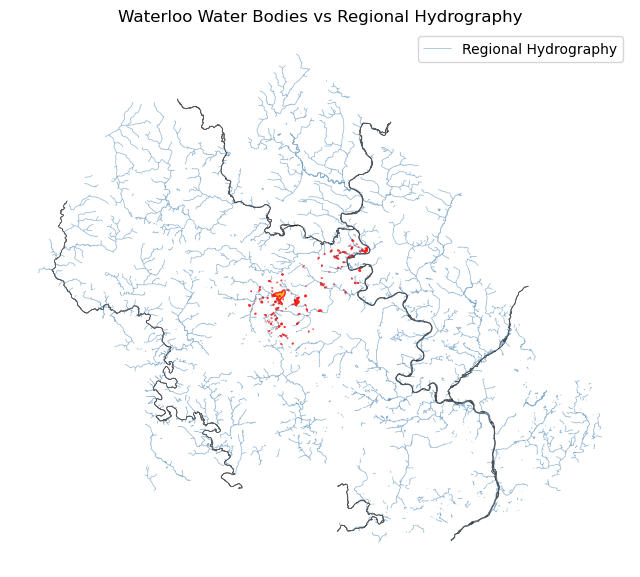

In [76]:
# Waterloo Water Bodies vs Regional Hydrography

compare_datasets(
    waterloo_water,
    regional_combined,
    "Waterloo Water Bodies",
    "Regional Hydrography"
)

C:\Users\brody\AppData\Local\Temp\ipykernel_20568\355364513.py:35: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


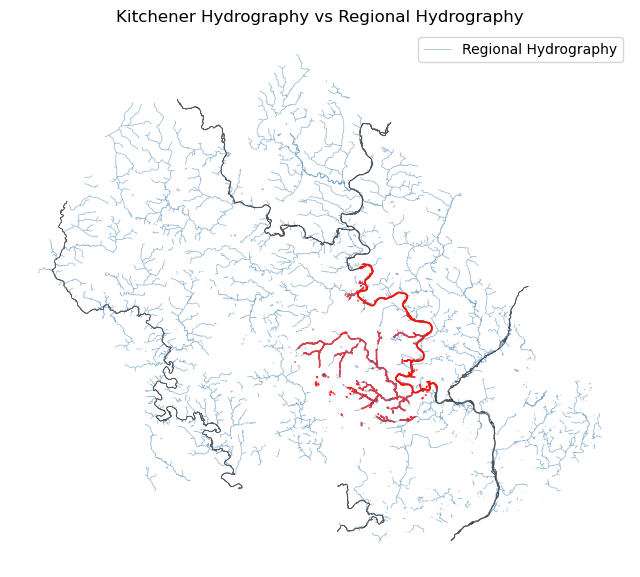

In [77]:
# Kitchener Hydrography vs Regional Hydrography

compare_datasets(
    kitchener_water,
    regional_combined,
    "Kitchener Hydrography",
    "Regional Hydrography"
)

## 7. Merge Analysis

Following visual inspection and containment testing, the next step is to determine whether any additional merging of datasets is required.

Suppose

\[
R
\]

represents the regional hydrography and

\[
M
\]

represents a municipal hydrography dataset.

Two possible situations may occur.

### Case 1 — No Additional Features Identified

If every municipal feature appears to be represented within the regional hydrography,

$$
M \approx R
$$

then no additional merging is required, and the unified hydrography is simply

$$
H = R.
$$

### Case 2 — Additional Municipal Features Identified

If one or more municipal features are not represented within the regional hydrography,

$$
M \not\approx R
$$

then those additional features are incorporated into the final hydrography layer,

$$
H = R \cup M.
$$

After merging, duplicate geometries are removed and the resulting dataset is validated before being saved for future ecological analyses.

Although the Waterloo Region datasets may ultimately require little or no merging, this workflow demonstrates a general methodology applicable to any geographic study area. It give you information to determine compatability of datasets, whether you should merge, what datasets to omit, and which to include.

In [78]:
# ============================================================
# Merge Helper
# ============================================================

def merge_if_needed(regional, municipal):

    contained = municipal.geometry.within(
        unary_union(regional.geometry)
    )

    if contained.all():

        print("No merge required.")
        print("Municipal dataset fully contained.")

        return regional.copy()

    print("Merge required.")
    print(f"Adding {(~contained).sum()} additional features.")

    merged = pd.concat(
        [
            regional,
            municipal.loc[~contained]
        ],
        ignore_index=True
    )

    return merged

In [79]:
# ============================================================
# Begin With Regional Dataset
# ============================================================

merged_water = regional_combined.copy()

In [80]:
merged_water = merge_if_needed(
    merged_water,
    waterloo_creeks
)

Merge required.
Adding 318 additional features.


In [81]:
merged_water = merge_if_needed(
    merged_water,
    waterloo_water
)

Merge required.
Adding 187 additional features.


In [82]:
merged_water = merge_if_needed(
    merged_water,
    kitchener_water
)

Merge required.
Adding 125 additional features.


### Remove Duplicate Geometries

Even after containment analysis, duplicate geometries may still exist due to overlapping regional datasets or differences in how individual organizations classify water features.

As a final preprocessing step, duplicate geometries are removed before saving the unified hydrography dataset. This produces a cleaner dataset for future analyses while preserving all unique water features.

In [83]:
# ============================================================
# Remove Duplicate Geometries
# ============================================================

merged_water = merged_water.drop_duplicates(
    subset="geometry"
).reset_index(drop=True)

print(f"Final Feature Count: {len(merged_water):,}")

Final Feature Count: 6,172


## 8. Save Unified Hydrography Dataset

Regardless of whether additional merging was required, the workflow always produces a single standardized hydrography layer.

Future notebooks should load only this dataset rather than returning to the original government sources. This simplifies later analyses while ensuring that every subsequent notebook operates from the same validated hydrography layer.

If no municipal features were added, the saved dataset is effectively identical to the regional hydrography. If additional features were incorporated, the saved dataset represents the union of all validated hydrographic information.

In [ ]:
# ============================================================
# Save Final Hydrography Dataset
# ============================================================

output_dir = data_dir / "Processed"

output_dir.mkdir(exist_ok=True)

output_path = output_dir / "merged_water.geojson"

merged_water.to_file(
    output_path,
    driver="GeoJSON"
)

print(f"Saved to:\n{output_path}")

## Conclusion

The objective of this notebook was initially to evaluate whether municipal and regional hydrography datasets could be combined into a single validated hydrography layer. During the analysis, however, several inconsistencies in dataset organization became apparent. Different jurisdictions classify and organize water features differently, resulting in datasets that are not directly comparable. Some municipalities separate rivers, creeks, and water bodies into individual datasets, whereas others combine multiple feature types into a single layer. Furthermore, equivalent regional datasets were not available for every municipal feature class.

Rather than forcing an uncertain merge, this notebook documents the evaluation process and the limitations encountered. The investigation nevertheless provided valuable insight into the structure of the available hydrography data and highlighted the importance of validating data compatibility before attempting automated integration.

Following this assessment, a more comprehensive data source was identified through the Ontario Hydro Network (OHN), which provides province-wide Watercourse and Waterbody datasets using a consistent classification system. Because these datasets avoid many of the compatibility issues identified here, subsequent notebooks will adopt the Ontario Hydro Network as the primary hydrography source for constructing the regional water model.

Although the Waterloo Region datasets were ultimately not selected as the primary hydrography source, the analysis performed in this notebook remains valuable because it demonstrates the practical challenges of integrating heterogeneous GIS datasets and illustrates an important stage in the scientific modeling process: evaluating data suitability before model construction.